In [13]:
import numpy as np
import pandas as pd

In [14]:
df = pd.read_csv('csvFiles/placement.csv')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [16]:
modified_df = pd.read_csv('csvFiles/modified_placement_data.csv')

In [17]:
modified_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       95 non-null     object 
 1   iq         100 non-null    float64
 2   placement  100 non-null    object 
dtypes: float64(1), object(2)
memory usage: 2.5+ KB


In [18]:
df.shape

(100, 4)

In [19]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [21]:
# first column is of no use remove that column 
df = df.iloc[: , 1:]

In [23]:
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [ ]:

# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [25]:
import matplotlib.pyplot as plt


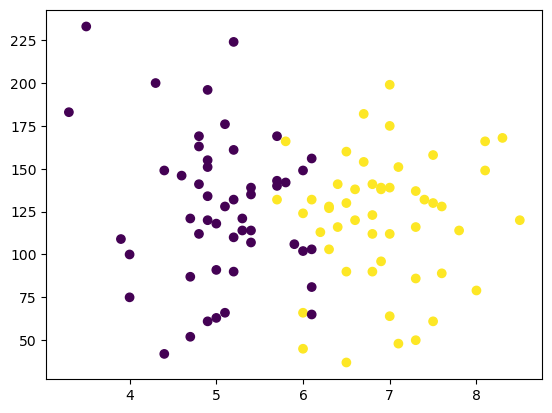

In [28]:
plt.scatter(df['cgpa'] , df['iq'] , c = df['placement'])

In [29]:
X = df.iloc[: , 0 : 2]
y = df.iloc[: , -1]

In [30]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [31]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X , y ,test_size=0.1)

In [32]:
X_train

,cgpa,iq
82,6.5,37.0
33,6.0,149.0
48,6.6,138.0
46,5.3,114.0
35,6.8,90.0
...,...,...
21,7.1,151.0
10,6.0,45.0
1,5.9,106.0
22,4.9,120.0


In [33]:
from sklearn.preprocessing import StandardScaler

# now all values between -1 to 1 

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

In [34]:
X_train

array([[ 0.44718034, -2.17912566],
       [ 0.00781101,  0.64131433],
       [ 0.53505421,  0.36430683],
       [-0.60730605, -0.24007317],
       [ 0.71080194, -0.84445316],
       [ 1.15017127, -0.18970817],
       [-1.74966631, -1.22219066],
       [ 0.7986758 , -0.69335816],
       [ 0.27143261,  0.11248183],
       [ 1.325919  ,  0.86795683],
       [ 1.15017127, -0.94518316],
       [ 0.88654967,  0.38948933],
       [ 0.09568488,  0.21321183],
       [-1.39817085, -2.05321316],
       [ 0.88654967, -0.29043817],
       [-0.69517992,  2.53000183],
       [-0.25581059,  0.21321183],
       [ 0.35930647,  0.43985433],
       [-0.16793672,  1.06941683],
       [-2.18903564,  2.75664433],
       [ 1.325919  , -1.57474566],
       [ 0.53505421, -0.08897817],
       [ 1.41379287, -0.86963566],
       [-0.87092765, -0.13934317],
       [-1.74966631, -0.59262817],
       [-1.04667538,  0.99386933],
       [-1.48604471,  1.92562183],
       [-0.25581059,  0.49021933],
       [ 2.20465766,

In [35]:
X_test = scaler.fit_transform(X_test)

In [37]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()

In [38]:
#Model training 

clf.fit(X_train , y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [39]:
y_pred = clf.predict(X_test)

In [40]:
from sklearn.metrics import accuracy_score

In [41]:
accuracy_score(y_pred , y_test)

0.9

In [45]:
!pip install mlxtend

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 2.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 8.2 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 8.5 MB/s  0:00:01 eta 0:00:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.7.2
    Uninstalling scikit-learn-1.7.2:
      Successfully uninstalled scikit-learn-1.7.2
  Attempting uninstall: matplotlib━━━━━━━━━━━━━━ 0/3 [scikit-learn]
    Found existing installation: matplotlib 3.10.60/3 [scikit-learn]
    Uninstalling matplotlib-3.10.6:━━━━━━━━━ 0/3 [scikit-learn]
      Successfully uninstalled matplotlib-3.10.6━━━━━━━━━━━━━━━━━━ 1/3 [matplotlib]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [mlxtend]m1/3 [matplotlib]


In [47]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

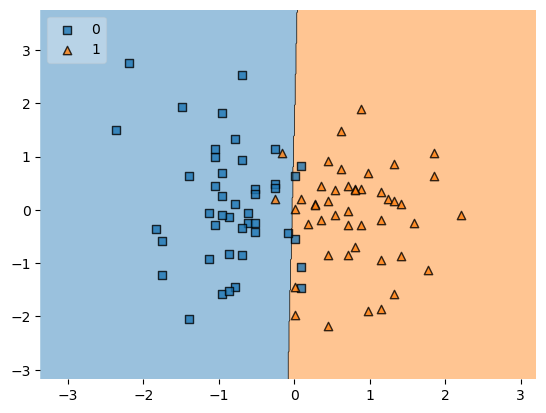

In [48]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [ ]:
# a Python module used to save and load trained models
import pickle

In [50]:

pickle.dump(clf,open('model.pkl','wb'))